In [34]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [35]:
import pandas as pd
import numpy as np
print('Libraries imported ✔️')

Libraries imported ✔️


In [36]:
file_path = '/content/drive/MyDrive/CIS450_LendingClub_Project/lending_club_rejected_loans.csv'

In [37]:
dtype_dict = {
    'Amount Requested': 'float64',          # numeric loan amount requested
    'Application Date': 'object',           # date string (parse later with pd.to_datetime)
    'Loan Title': 'object',                 # categorical / text
    'Risk_Score': 'float64',                # numeric credit/risk score (may contain NaNs or special values)
    'Debt-To-Income Ratio': 'object',       # string like "15.5%" or "NA" – clean later
    'Zip Code': 'object',                   # string (e.g., "123xx")
    'State': 'object',                      # categorical (2-letter state code)
    'Employment Length': 'object',          # string (e.g., "10+ years", "< 1 year", "n/a")
    'Policy Code': 'float64'                  # categorical / integer code (usually 0 or 1)
}

In [38]:
usecols = list(dtype_dict.keys())
print('Ready to load data...')

Ready to load data...


In [39]:
df_sample = pd.read_csv(
    file_path,
    usecols=usecols,
    dtype=dtype_dict,
    low_memory=False,
    skiprows=lambda i: i > 0 and np.random.rand() > 0.05
)
print('Sample dataset completed')

Sample dataset completed


In [40]:
df_sample.head()

,Amount Requested,Application Date,Loan Title,Risk_Score,Debt-To-Income Ratio,Zip Code,State,Employment Length,Policy Code
0,3900.0,2007-05-28,need to consolidate,710.0,10%,705xx,LA,10+ years,0.0
1,12000.0,2007-05-29,Finish Off College,704.0,10%,462xx,IN,2 years,0.0
2,15000.0,2007-06-01,joelforeman,654.0,27.48%,328xx,FL,2 years,0.0
3,3500.0,2007-06-08,tmsworld,583.0,3.12%,100xx,NY,< 1 year,0.0
4,5000.0,2007-06-08,thephotoguy.seth,545.0,10.18%,337xx,TN,< 1 year,0.0


In [41]:
print(df_sample.shape)

(1383549, 9)


In [42]:
missing = df_sample.isnull().sum().sort_values(ascending=False)
print('Top missing columns:\n', missing.head(15))

Top missing columns:
 Risk_Score              925444
Employment Length        47774
Loan Title                  72
Policy Code                 47
Zip Code                    16
State                        3
Amount Requested             0
Debt-To-Income Ratio         0
Application Date             0
dtype: int64


In [43]:
df_clean = df_sample.dropna(subset=['Risk_Score', 'Policy Code', 'Employment Length','Loan Title', 'Zip Code', 'State']).copy()

print(f"Original rows: {len(df_sample):,}")
print(f"Rows after dropping missing key vars: {len(df_clean):,}")
print(f"Rows lost: {len(df_sample) - len(df_clean):,} ({(len(df_sample)-len(df_clean))/len(df_sample)*100:.2f}%)")




Original rows: 1,383,549
Rows after dropping missing key vars: 450,261
Rows lost: 933,288 (67.46%)


In [44]:
df_clean['Application Date'] = pd.to_datetime(df_clean['Application Date'], errors='coerce')

In [45]:
df_clean['Debt-To-Income Ratio'] = (
    df_clean['Debt-To-Income Ratio']
    .str.rstrip('%')
    .replace('NA', np.nan)
    .astype(float) # convert to number
)

print('DTI conversion completed (now in percentage scale like accepted file)')
print('Sample values:', df_clean['Debt-To-Income Ratio'].head().tolist())
print('DTI mean:', round(df_clean['Debt-To-Income Ratio'].mean(), 2))

DTI conversion completed (now in percentage scale like accepted file)
Sample values: [10.0, 10.0, 27.48, 3.12, 10.18]
DTI mean: 150.44


In [46]:
print(df_clean['Debt-To-Income Ratio'].describe())

count    4.502610e+05
mean     1.504417e+02
std      4.641771e+03
min     -1.000000e+00
25%      9.030000e+00
50%      2.053000e+01
75%      3.617000e+01
max      1.362000e+06
Name: Debt-To-Income Ratio, dtype: float64


In [47]:
df_clean['Employment Length'] = pd.to_numeric(
    df_clean['Employment Length'].str.extract(r'(\d+)')[0],
    errors='coerce'
)

In [48]:
print(df_clean.info())
print(df_clean.isnull().sum())

<class 'pandas.core.frame.DataFrame'>
Index: 450261 entries, 0 to 1383548
Data columns (total 9 columns):
 #   Column                Non-Null Count   Dtype         
---  ------                --------------   -----         
 0   Amount Requested      450261 non-null  float64       
 1   Application Date      450261 non-null  datetime64[ns]
 2   Loan Title            450261 non-null  object        
 3   Risk_Score            450261 non-null  float64       
 4   Debt-To-Income Ratio  450261 non-null  float64       
 5   Zip Code              450261 non-null  object        
 6   State                 450261 non-null  object        
 7   Employment Length     450261 non-null  int64         
 8   Policy Code           450261 non-null  float64       
dtypes: datetime64[ns](1), float64(4), int64(1), object(3)
memory usage: 34.4+ MB
None
Amount Requested        0
Application Date        0
Loan Title              0
Risk_Score              0
Debt-To-Income Ratio    0
Zip Code                0
St

In [49]:
# Normalize Loan Title
df_clean['Loan_Purpose'] = df_clean['Loan Title'].str.lower().str.strip()

# Simple mapping for common purposes (expand as needed)
purpose_map = {
    'debt consolidation': 'Debt Consolidation',
    'debt_consolidation': 'Debt Consolidation',
    'credit card refinancing': 'Credit Card',
    'credit_card': 'Credit Card',
    'home improvement': 'Home Improvement',
    'home_improvement': 'Home Improvement',
    'other': 'Other',
    'car financing': 'Car Financing',
    'medical expenses': 'Medical'
}
df_clean['Loan_Purpose'] = df_clean['Loan_Purpose'].replace(purpose_map).fillna('Other')

# Policy Code as category and flag
df_clean['Policy_Code_Group'] = df_clean['Policy Code'].map({0.0: 'Standard Decline', 2.0: 'Policy 2 (Special)'})
df_clean['Policy_Code_Group'] = df_clean['Policy_Code_Group'].fillna('Standard Decline')

print("Normalized Loan Purpose top 10:\n", df_clean['Loan_Purpose'].value_counts().head(10))
print("\nPolicy Code Group:\n", df_clean['Policy_Code_Group'].value_counts())

Normalized Loan Purpose top 10:
 Loan_Purpose
Debt Consolidation       207586
Other                     68787
Credit Card               56115
Home Improvement          20505
Car Financing             15116
car                        8477
Medical                    7878
small_business             6770
major_purchase             6569
moving and relocation      6530
Name: count, dtype: int64

Policy Code Group:
 Policy_Code_Group
Standard Decline      449532
Policy 2 (Special)       729
Name: count, dtype: int64


In [50]:
df_clean['Year'] = df_clean['Application Date'].dt.year
df_clean['Quarter'] = df_clean['Application Date'].dt.quarter

In [51]:
print('Debt-To-Income Ratio is now in PERCENTAGE scale (same as accepted dti)')
df_clean.describe()

Debt-To-Income Ratio is now in PERCENTAGE scale (same as accepted dti)


,Amount Requested,Application Date,Risk_Score,Debt-To-Income Ratio,Employment Length,Policy Code,Year,Quarter
count,450261.000000,450261,450261.000000,4.502610e+05,450261.000000,450261.000000,450261.000000,450261.000000
mean,12607.902894,2016-01-18 17:40:13.600111872,627.116239,1.504417e+02,1.427485,0.003238,2015.494920,2.730045
min,300.000000,2007-05-28 00:00:00,0.000000,-1.000000e+00,1.000000,0.000000,2007.000000,1.000000
25%,4000.000000,2014-07-16 00:00:00,590.000000,9.030000e+00,1.000000,0.000000,2014.000000,2.000000
50%,10000.000000,2016-12-14 00:00:00,636.000000,2.053000e+01,1.000000,0.000000,2016.000000,3.000000
75%,20000.000000,2017-10-04 00:00:00,674.000000,3.617000e+01,1.000000,0.000000,2017.000000,4.000000
max,250000.000000,2018-12-31 00:00:00,990.000000,1.362000e+06,10.000000,2.000000,2018.000000,4.000000
std,10858.595367,NaN,90.236522,4.641771e+03,1.642313,0.080410,2.010828,1.177299


In [52]:
df_clean.shape


(450261, 13)

In [53]:
drive_path = '/content/drive/MyDrive/CIS450_LendingClub_Project/rejected_cleaned_sample.csv'
df_clean.to_csv(drive_path, index=False)
print(f"Saved to Google Drive: {drive_path}")

Saved to Google Drive: /content/drive/MyDrive/CIS450_LendingClub_Project/rejected_cleaned_sample.csv


In [54]:
import matplotlib.pyplot as plt
import seaborn as sns

In [55]:
sns.set(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)

In [56]:
print("\n=== Numeric Summary ===")
print(df_clean[['Amount Requested', 'Risk_Score', 'Debt-To-Income Ratio',
          'Employment Length']].describe())

print("\n=== Categorical Summary ===")
print("Policy Code value counts:\n", df_clean['Policy Code'].value_counts())
print("\nTop 10 Loan Titles:\n", df_clean['Loan Title'].value_counts().head(10))
print("\nTop 10 States:\n", df_clean['State'].value_counts().head(10))


=== Numeric Summary ===
       Amount Requested     Risk_Score  Debt-To-Income Ratio  \
count     450261.000000  450261.000000          4.502610e+05   
mean       12607.902894     627.116239          1.504417e+02   
std        10858.595367      90.236522          4.641771e+03   
min          300.000000       0.000000         -1.000000e+00   
25%         4000.000000     590.000000          9.030000e+00   
50%        10000.000000     636.000000          2.053000e+01   
75%        20000.000000     674.000000          3.617000e+01   
max       250000.000000     990.000000          1.362000e+06   

       Employment Length  
count      450261.000000  
mean            1.427485  
std             1.642313  
min             1.000000  
25%             1.000000  
50%             1.000000  
75%             1.000000  
max            10.000000  

=== Categorical Summary ===
Policy Code value counts:
 Policy Code
0.0    449532
2.0       729
Name: count, dtype: int64

Top 10 Loan Titles:
 Loan Title


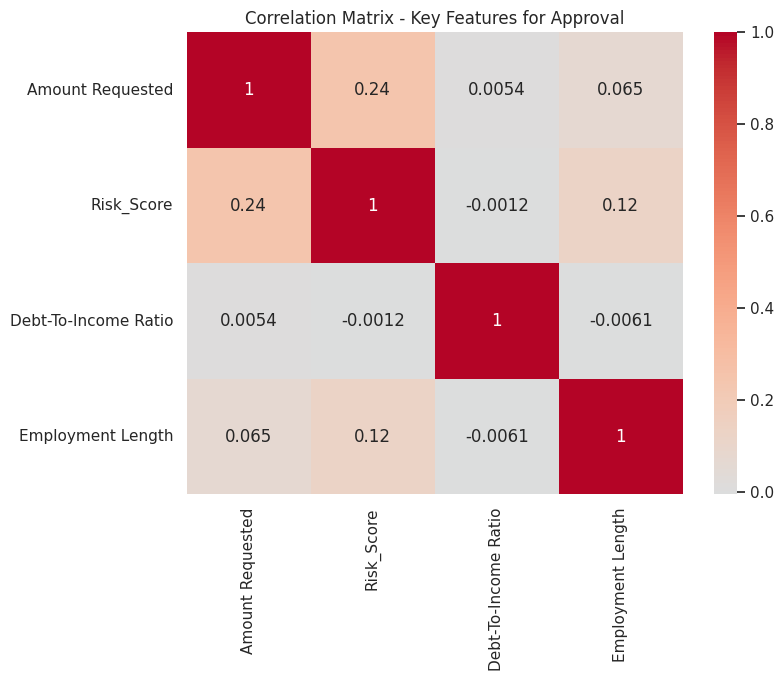

In [57]:
# Most Important Characteristics for Approval/Decline
numeric_cols = ['Amount Requested', 'Risk_Score', 'Debt-To-Income Ratio', 'Employment Length']
corr = df_clean[numeric_cols].corr()

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Correlation Matrix - Key Features for Approval')
plt.show()

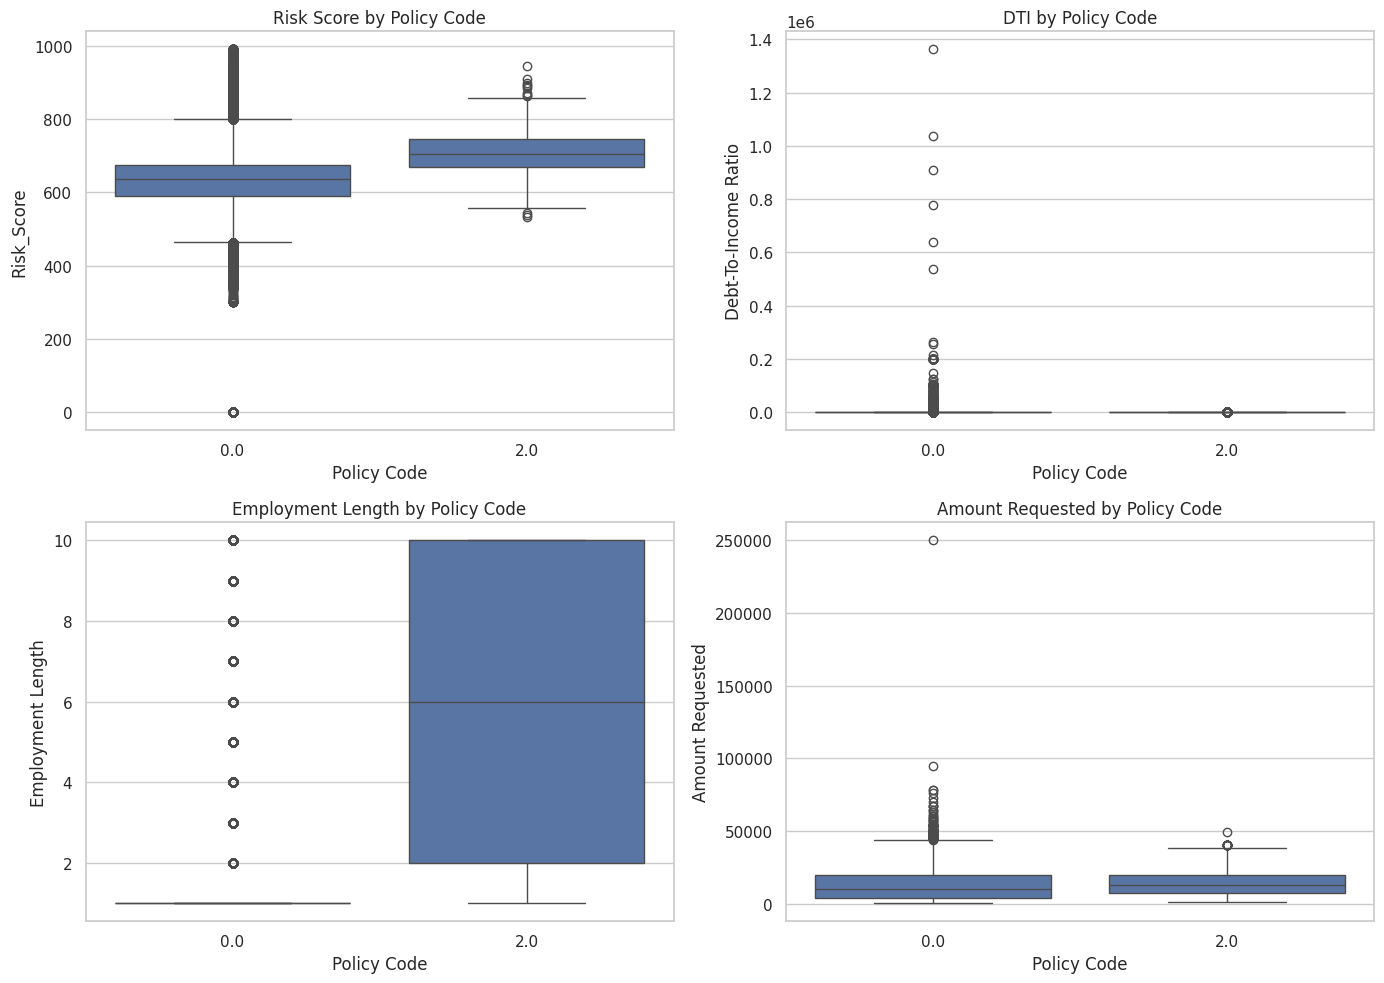

In [59]:
# How features differ by Policy Code
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
sns.boxplot(x='Policy Code', y='Risk_Score', data=df_clean, ax=axes[0,0])
axes[0,0].set_title('Risk Score by Policy Code')

sns.boxplot(x='Policy Code', y='Debt-To-Income Ratio', data=df_clean, ax=axes[0,1])
axes[0,1].set_title('DTI by Policy Code')

sns.boxplot(x='Policy Code', y='Employment Length', data=df_clean, ax=axes[1,0])
axes[1,0].set_title('Employment Length by Policy Code')

sns.boxplot(x='Policy Code', y='Amount Requested', data=df_clean, ax=axes[1,1])
axes[1,1].set_title('Amount Requested by Policy Code')
plt.tight_layout()
plt.show()

In [60]:
# Factors for Loan Succes / Default Likelihoood
print("\n=== Q2: Factors Most Important for Success vs Default ===")

df_clean['Risk_Score_Bin'] = pd.cut(df_clean['Risk_Score'], bins=[0, 600, 700, 800, 850],
                              labels=['<600', '600-700', '700-800', '>800'])

success_factors = df_clean.groupby('Risk_Score_Bin')[['Debt-To-Income Ratio', 'Employment Length']].mean()
print(success_factors)



=== Q2: Factors Most Important for Success vs Default ===
                Debt-To-Income Ratio  Employment Length
Risk_Score_Bin                                         
<600                      115.256738           1.162143
600-700                   127.715801           1.435821
700-800                   261.049545           1.955988
>800                      770.186553           2.286749


/tmp/ipykernel_4718/3648447341.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  success_factors = df_clean.groupby('Risk_Score_Bin')[['Debt-To-Income Ratio', 'Employment Length']].mean()


In [61]:
# Missed Good Loans (Declined but likely to Suceed)
print("\n=== Q3: Potential Missed Good Loans ===")
good_profile = (
    (df_clean['Risk_Score'] >= 680) &
    (df_clean['Debt-To-Income Ratio'] <= 30) &
    (df_clean['Employment Length'] >= 2) &
    (df_clean['Amount Requested'] <= 35000)
)

missed_loans = df_clean[good_profile & (df_clean['Policy Code'] == 0)]   # Policy Code 0 = declined

print(f"Number of potential 'Missed Good Loans': {len(missed_loans):,}")
print("\nSummary of Missed Good Loans:")
print(missed_loans[['Risk_Score', 'Debt-To-Income Ratio', 'Employment Length',
                    'Amount Requested', 'Loan Title','State']].describe())


=== Q3: Potential Missed Good Loans ===
Number of potential 'Missed Good Loans': 12,431

Summary of Missed Good Loans:
         Risk_Score  Debt-To-Income Ratio  Employment Length  Amount Requested
count  12431.000000          12431.000000       12431.000000      12431.000000
mean     722.913362             13.550677           6.485802      16158.225788
std       42.222170              8.428033           2.904338      10420.594069
min      680.000000             -1.000000           2.000000       1000.000000
25%      693.000000              6.565000           4.000000       7500.000000
50%      711.000000             13.340000           5.000000      15000.000000
75%      739.000000             20.225000          10.000000      25000.000000
max      990.000000             30.000000          10.000000      35000.000000


In [62]:
print("\nSample of 10 Missed Good Loans:")
print(missed_loans[['Amount Requested', 'Risk_Score', 'Debt-To-Income Ratio',
                    'Employment Length', 'State', 'Loan Title']].head(10))


Sample of 10 Missed Good Loans:
     Amount Requested  Risk_Score  Debt-To-Income Ratio  Employment Length  \
0              3900.0       710.0                 10.00                 10   
1             12000.0       704.0                 10.00                  2   
24             6500.0       715.0                 16.57                  3   
134           16000.0       698.0                 18.69                  3   
142            5000.0       690.0                  0.00                  6   
143           25000.0       699.0                 29.72                  3   
182            6500.0       727.0                 15.40                  6   
186           20000.0       703.0                 11.91                 10   
217           11000.0       716.0                  4.30                  2   
220            5000.0       689.0                 25.05                  4   

    State             Loan Title  
0      LA    need to consolidate  
1      IN     Finish Off College  
24 

In [64]:
print('\nTop 10 Loan Purposes in Missed Good Loans:')
print(missed_loans['Loan Title'].value_counts().head(10))


Top 10 Loan Purposes in Missed Good Loans:
Loan Title
Debt consolidation         3093
Credit card refinancing    1224
debt_consolidation         1006
other                       711
Home improvement            552
Other                       539
Business                    426
car                         413
home_improvement            270
Major purchase              262
Name: count, dtype: int64


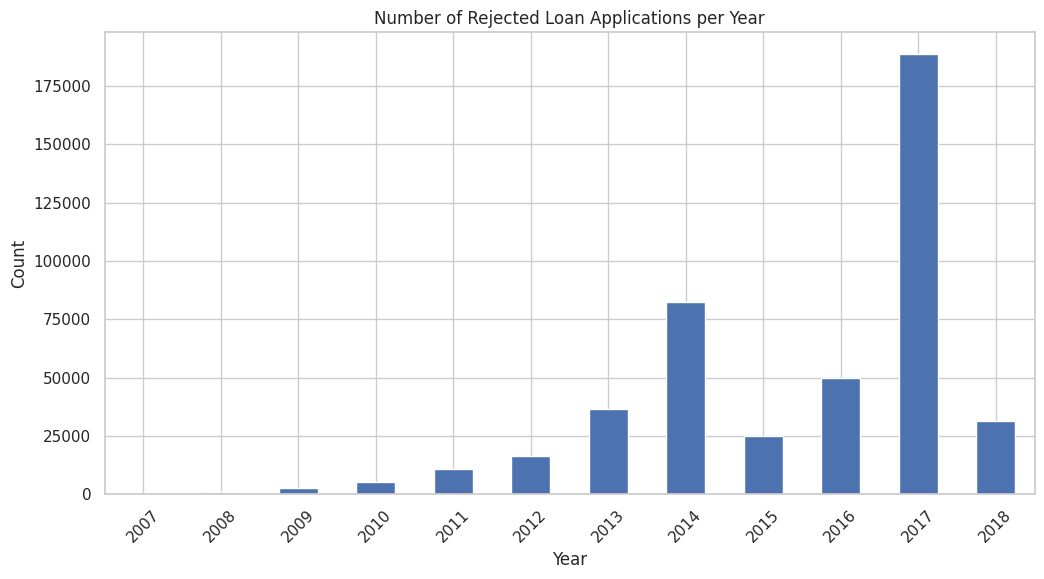

In [65]:
# Trenprint("\n=== Q4: Trends Over Time (2007–2020) ===")

df_clean['Year'] = pd.to_datetime(df_clean['Application Date']).dt.year

annual_rejects = df_clean['Year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
annual_rejects.plot(kind='bar')
plt.title('Number of Rejected Loan Applications per Year')
plt.xlabel('Year')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

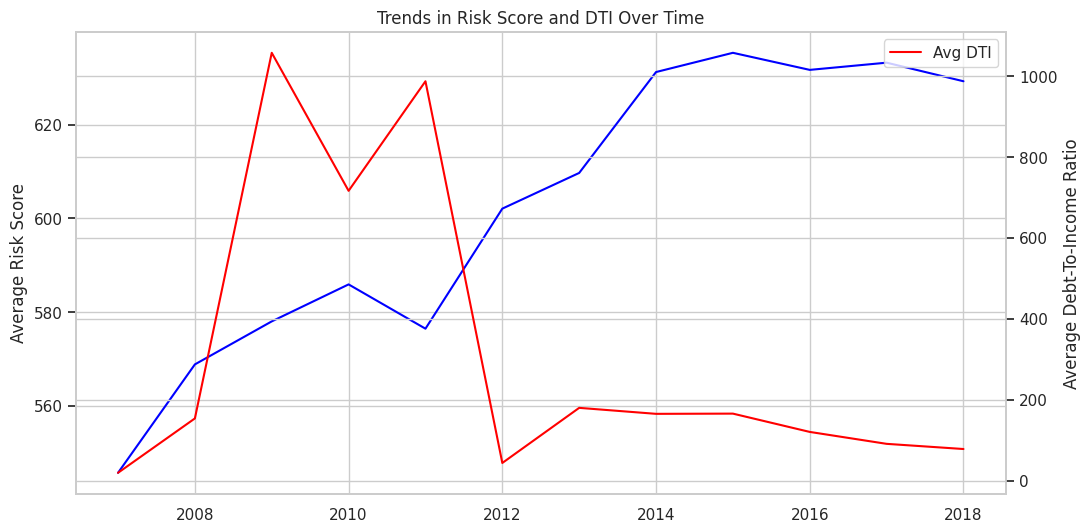

In [66]:
# Average Risk Score & DTI over time

trend = df_clean.groupby('Year')[['Risk_Score', 'Debt-To-Income Ratio']].mean()

fig, ax1 = plt.subplots(figsize=(12,6))
ax1.plot(trend.index, trend['Risk_Score'], color='blue', label='Avg Risk Score')
ax1.set_ylabel('Average Risk Score')
ax2 = ax1.twinx()
ax2.plot(trend.index, trend['Debt-To-Income Ratio'], color='red', label='Avg DTI')
ax2.set_ylabel('Average Debt-To-Income Ratio')
plt.title('Trends in Risk Score and DTI Over Time')
plt.legend()
plt.show()

In [67]:
# Top Loan Titiles among missed good loans
print("\nTop Loan Purposes in Missed Good Loans:")
print(missed_loans['Loan Title'].value_counts().head(10))


Top Loan Purposes in Missed Good Loans:
Loan Title
Debt consolidation         3093
Credit card refinancing    1224
debt_consolidation         1006
other                       711
Home improvement            552
Other                       539
Business                    426
car                         413
home_improvement            270
Major purchase              262
Name: count, dtype: int64


In [68]:
# Rejection patterns by State (top 10 states by volume)
state_reject = df_clean['State'].value_counts().head(10)
print("\nTop 10 States by Rejection Volume:\n", state_reject)


Top 10 States by Rejection Volume:
 State
CA    54017
TX    40350
FL    34855
NY    33282
PA    17723
GA    17173
IL    16566
OH    16411
NC    14129
NJ    14005
Name: count, dtype: int64


In [69]:
drive_path = '/content/drive/MyDrive/CIS450_LendingClub_Project/missed_good_loans.csv'
missed_loans.to_csv(drive_path, index=False)
print(f"Saved to Google Drive: {drive_path}")



Saved to Google Drive: /content/drive/MyDrive/CIS450_LendingClub_Project/missed_good_loans.csv
